In [167]:
%matplotlib inline

from utils import *
import os
import matplotlib.pyplot as plt
import numpy as np

In [168]:
ns0, ts0 = load_traces_from_directory('traces/compare/pbcts/', protocols_to_skip=['bc', 'bc_send'])
ns1, ts1 = load_traces_from_directory('traces/compare/mul/')
ns2, ts2 = load_traces_from_directory('traces/compare/rand/', protocols_to_skip=['bc', 'bc_send'])

ns = ns0

In [169]:
pbcts_total_sent = get_average_sent_all_parties(ts0)

pbcts_total_recv = get_average_recv_all_parties(ts0)

ours_total_sent = get_average_sent_all_parties(ts1) \
    + get_average_sent_all_parties(ts2)

ours_total_recv = get_average_recv_all_parties(ts1) \
    + get_average_recv_all_parties(ts2)

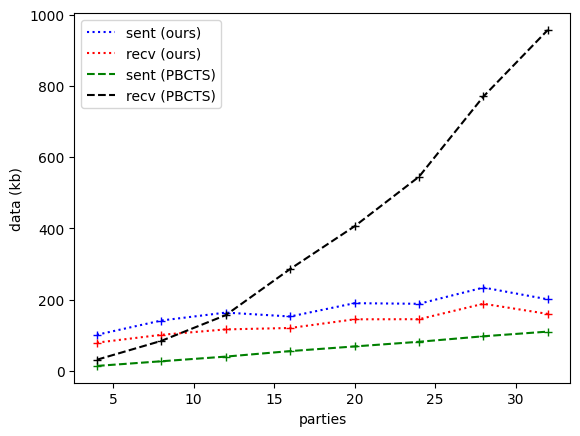

In [174]:
###
### Experiment 5. Communication
###

plt.plot(ns0, np.median(ours_total_sent, axis=1) / 1024.0, ':b', label='sent (ours)')
plt.plot(ns0, np.median(ours_total_sent, axis=1) / 1024.0, '+b')

plt.plot(ns0, np.median(ours_total_recv, axis=1) / 1024.0, ':r', label='recv (ours)')
plt.plot(ns0, np.median(ours_total_recv, axis=1) / 1024.0, '+r')

plt.plot(ns0, np.median(pbcts_total_sent, axis=1) / 1024.0, '--g', label='sent (PBCTS)')
plt.plot(ns0, np.median(pbcts_total_sent, axis=1) / 1024.0, '+g')

plt.plot(ns0, np.median(pbcts_total_recv, axis=1) / 1024.0, '--k', label='recv (PBCTS)')
plt.plot(ns0, np.median(pbcts_total_recv, axis=1) / 1024.0, '+k')

plt.xlabel('parties')
plt.ylabel('data (kb)')
plt.legend()
#plt.show()
#plt.savefig('exp5_comm.png')

In [175]:
pbcts_total = get_average_execution_time_all_parties(ts0)

ours_total = get_average_execution_time_all_parties(ts1) \
    + get_average_execution_time_all_parties(ts2)

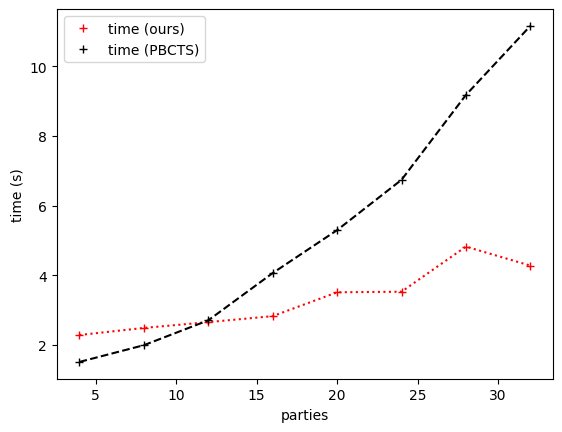

In [176]:
###
### Experiment 5: Execution time
###

plt.plot(ns0, np.median(ours_total, axis=1) / 1000.0, '+r', label='time (ours)')
plt.plot(ns0, np.median(ours_total, axis=1) / 1000.0, ':r')

plt.plot(ns0, np.median(pbcts_total, axis=1) / 1000.0, '+k', label='time (PBCTS)')
plt.plot(ns0, np.median(pbcts_total, axis=1) / 1000.0, '--k')

plt.xlabel('parties')
plt.ylabel('time (s)')
plt.legend()
#plt.show()
#plt.savefig('exp5_time.png')

In [177]:
ns, ts = load_traces_from_directory('traces/sign/')

In [178]:
ss0 = get_total_sent_of(ts, 'send, recv') / 1024.0
rs0 = get_total_recv_of(ts, 'send, recv') / 1024.0

xs = np.median(ss0, axis=1)
xr = np.median(rs0, axis=1)

#print('sent:')
#print(xs)
#print('recv:')
#print(xr)

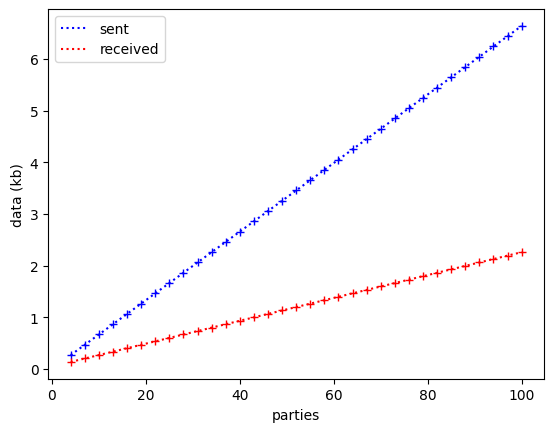

In [179]:
###
### Experiment 1: Communication
###

plt.plot(ns, xs, ':b', label='sent')
plt.plot(ns, xs, '+b')

plt.plot(ns, xr, ':r', label='received')
plt.plot(ns, xr, '+r')

plt.xlabel('parties')
plt.ylabel('data (kb)')
plt.legend()
#plt.show()
#plt.savefig('exp1_comm.png')

In [180]:
tsign = get_execution_time_of(ts, 'send, recv')
trecover = get_execution_time_of(ts, 'recover')

xsig = np.median(tsign, axis=1)
xrec = np.median(trecover, axis=1)
xtot = np.median(tsign + trecover, axis=1)

#print('time spent receiving shares:')
#print(xsig)

#print('time spent reconstructing signature:')
#print(xrec)

#print('total execution time:')
#print(xtot)

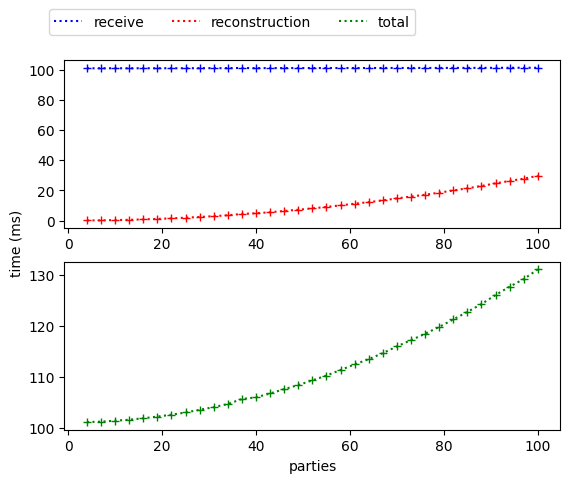

In [181]:
###
### Experiment 1: Execution time
###

fig, (ax0, ax1) = plt.subplots(2, 1)

ax0.plot(ns, xsig, ':b', label='receive')
ax0.plot(ns, xsig, '+b')

ax0.plot(ns, xrec, ':r', label='reconstruction')
ax0.plot(ns, xrec, '+r')

ax1.plot(ns, xtot, ':g', label='total')
ax1.plot(ns, xtot, '+g')

ax1.set_xlabel('parties')
fig.text(0.04, 0.5, 'time (ms)', va='center', rotation='vertical')

fig.legend(loc='upper left', bbox_to_anchor=(0.09, 1), ncol=3)

#plt.show()
#plt.savefig('exp1_time.png')

In [194]:
ns, ts = load_traces_from_directory('traces/mul/')
get_protocol_names(ts[0], 0)

['Batch and prove', 'Recv, verify, correct']

In [195]:
ss0 = get_average_sent_all_parties(ts) / 1024.0
rs0 = get_average_recv_all_parties(ts) / 1024.0

xs = np.median(ss0, axis=1)
xr = np.median(rs0, axis=1)

#print('sent:')
#print(xs)
#print('recv:')
#print(xr)

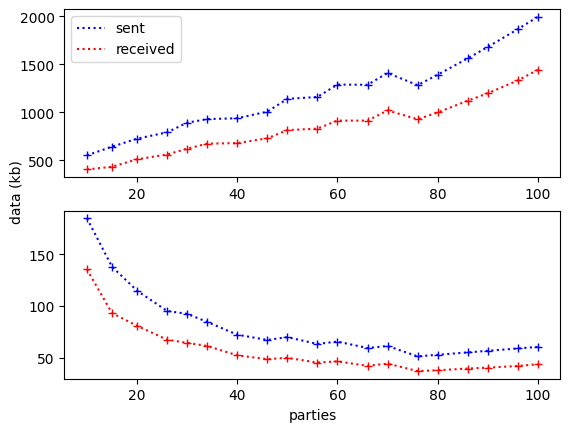

In [196]:
###
### Experiment 2: Communication
###

fig, (ax0, ax1) = plt.subplots(2, 1)

ax1.set_xlabel('parties')

ax0.plot(ns, xs, ':b', label='sent')
ax0.plot(ns, xs, '+b')

ax0.plot(ns, xr, ':r', label='received')
ax0.plot(ns, xr, '+r')

ax1.plot(ns, xs / ((ns - 1) / 3), ':b', label='sent')
ax1.plot(ns, xs / ((ns - 1) / 3), '+b')

ax1.plot(ns, xr / ((ns - 1) / 3), ':r', label='received')
ax1.plot(ns, xr / ((ns - 1) / 3), '+r')

fig.text(0.04, 0.5, 'data (kb)', va='center', rotation='vertical')

plt.legend(loc='upper left', bbox_to_anchor=(0, 2.2))
#plt.show()
#plt.savefig('exp2_comm.png')

In [197]:
et0 = get_average_execution_time_all_parties(ts, name_filter=['Batch and prove']) / 1000.0
et1 = get_average_execution_time_all_parties(ts, name_filter=['Recv, verify, correct']) / 1000.0

t0 = np.median(et0, axis=1)
t1 = np.median(et1, axis=1)
t2 = np.median(et0 + et1, axis=1)

#print('execution times:')
#print('1st:  ', t0)
#print('2nd:  ', t1)

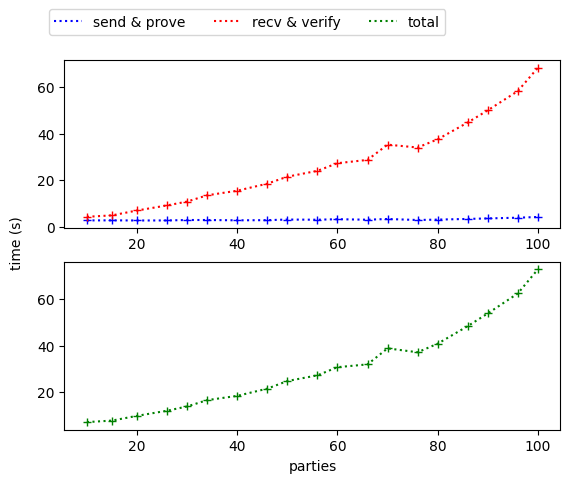

In [198]:
###
### Experiment 2: Execution time
###

fig, (ax0, ax1) = plt.subplots(2, 1)

ax0.plot(ns, t0, ':b', label='send & prove')
ax0.plot(ns, t0, '+b')

ax0.plot(ns, t1, ':r', label='recv & verify')
ax0.plot(ns, t1, '+r')

ax1.plot(ns, t2, ':g', label='total')
ax1.plot(ns, t2, '+g')

ax1.set_xlabel('parties')
fig.text(0.04, 0.5, 'time (s)', va='center', rotation='vertical')

fig.legend(loc='upper left', bbox_to_anchor=(0.09, 1), ncol=3)
#plt.show()
#plt.savefig('exp2_time.png')

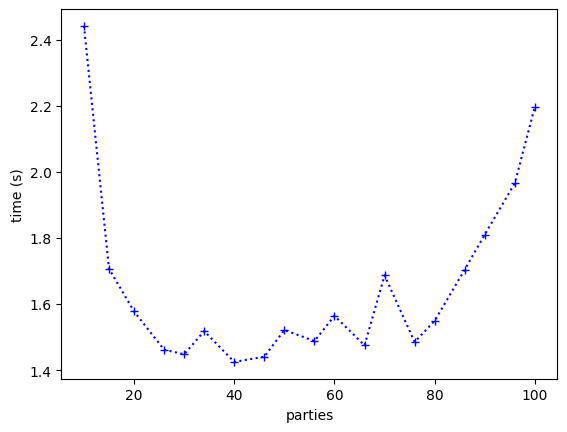

In [200]:
###
### Experiment 2: Execution time per mul
###

plt.plot(ns, t2 / ((ns - 1) / 3), ':b')
plt.plot(ns, t2 / ((ns - 1) / 3), '+b')

plt.xlabel('parties')
plt.ylabel('time (s)')

#plt.show()
plt.savefig('exp2_time_per.png')

In [188]:
ns, ts = load_traces_from_directory('traces/rand/', protocols_to_skip=['bc', 'bc_send'])
get_protocol_names(ts[0])

[['share', 'complain', 'fill', 'fill-exchange', 'finalize', 'extract'],
 ['share', 'complain', 'fill', 'fill-exchange', 'finalize', 'extract'],
 ['share', 'complain', 'fill', 'fill-exchange', 'finalize', 'extract'],
 ['share', 'complain', 'fill', 'fill-exchange', 'finalize', 'extract'],
 []]

In [189]:
share_time = get_average_execution_time_all_parties(ts, name_filter=['share'])
agree_time = get_average_execution_time_all_parties(ts, name_filter=['complain', 'fill', 'fill-exchange', 'finalize'])
extract_time = get_execution_time_of(ts, 'extract')
total_time = share_time + agree_time + extract_time

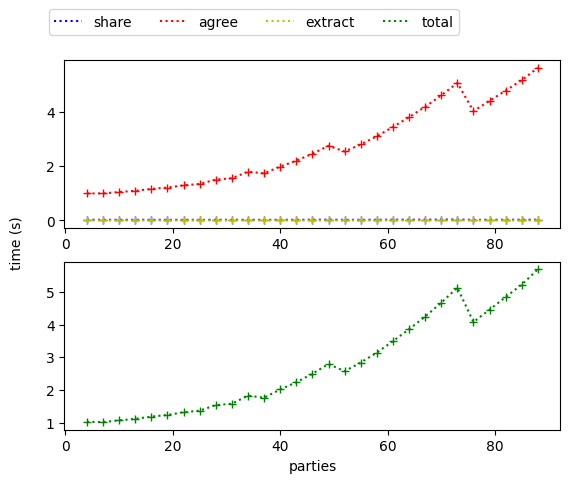

In [190]:
###
### Experiment 3: Execution time
###

fig, (ax0, ax1) = plt.subplots(2, 1)

ax0.plot(ns, np.median(share_time, axis=1) / 1000.0, ':b', label='share')
ax0.plot(ns, np.median(share_time, axis=1) / 1000.0, '+b')

ax0.plot(ns, np.median(agree_time, axis=1)  / 1000.0, ':r', label='agree')
ax0.plot(ns, np.median(agree_time, axis=1)  / 1000.0, '+r')

ax0.plot(ns, np.median(extract_time, axis=1) / 1000.0, ':y', label='extract')
ax0.plot(ns, np.median(extract_time, axis=1) / 1000.0, '+y')

ax1.plot(ns, np.median(total_time, axis=1) / 1000.0, ':g', label='total')
ax1.plot(ns, np.median(total_time, axis=1) / 1000.0, '+g')

ax1.set_xlabel('parties')
fig.text(0.04, 0.5, 'time (s)', va='center', rotation='vertical')

fig.legend(loc='upper left', bbox_to_anchor=(0.09, 1), ncol=4)

#plt.show()
#plt.savefig('exp3_time.png')

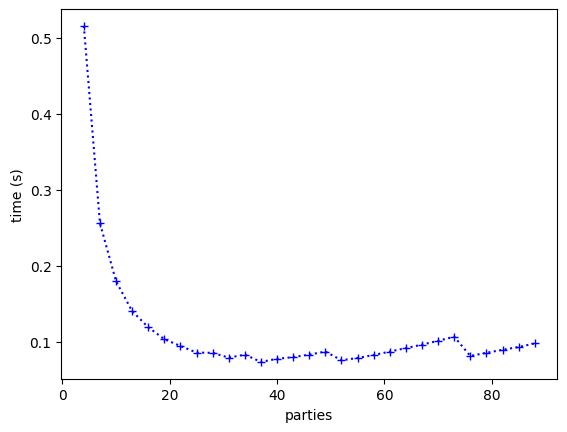

In [191]:
###
### Experiment 3: Execution time per mul
###

plt.plot(ns, np.median(total_time / 1000, axis=1) / ((2*(ns - 1)) / 3), ':b')
plt.plot(ns, np.median(total_time / 1000, axis=1) / ((2*(ns - 1)) / 3), '+b')

plt.xlabel('parties')
plt.ylabel('time (s)')

#plt.show()
#plt.savefig('exp3_time_per.png')

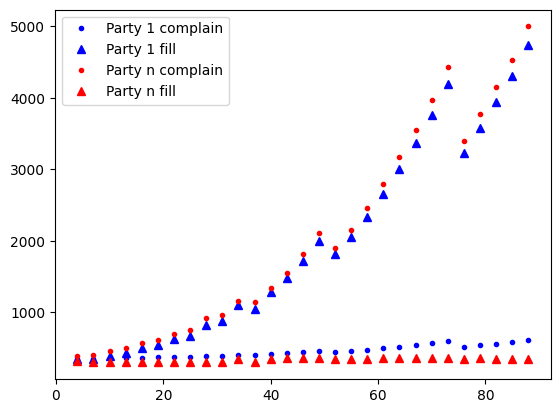

In [192]:
###
### Experiment 3: complain and fill execution time.
###

complain_0 = get_execution_time_of(ts, 'complain', 0)
fill_0 = get_execution_time_of(ts, 'fill', 0)

complain_n = get_execution_time_of(ts, 'complain', -2)
fill_n = get_execution_time_of(ts, 'fill', -2)


plt.plot(ns, np.median(complain_0, axis=1), 'b.', label='Party 1 complain')
plt.plot(ns, np.median(fill_0, axis=1), 'b^', label='Party 1 fill')

plt.plot(ns, np.median(complain_n, axis=1), 'r.', label='Party n complain')
plt.plot(ns, np.median(fill_n, axis=1), 'r^', label='Party n fill')

plt.legend()
#plt.show()
#plt.savefig('exp3_complain_and_fill_time.png')

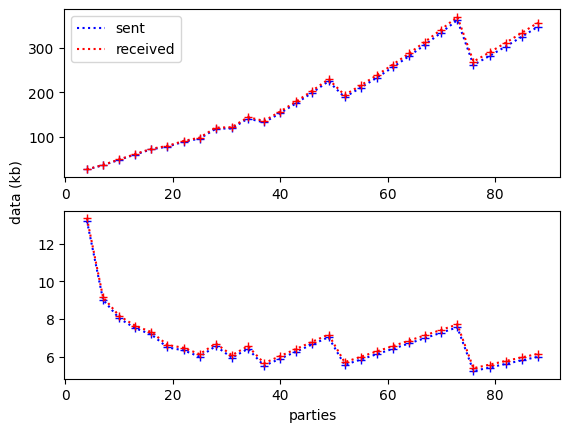

In [193]:
###
### Experiment 3: Communication
###

fig, (ax0, ax1) = plt.subplots(2, 1)

sent = get_total_sent_of(ts, 'share') \
    + get_total_sent_of(ts, 'complain') \
    + get_total_sent_of(ts, 'fill-exchange')

recv = get_total_recv_of(ts, 'complain') \
    + get_total_recv_of(ts, 'fill') \
    + get_total_recv_of(ts, 'finalize')
    
ax0.plot(ns, np.median(sent / 1024.0, axis=1), ':b', label='sent')
ax0.plot(ns, np.median(sent / 1024.0, axis=1), '+b')

ax0.plot(ns, np.median(recv / 1024.0, axis=1), ':r', label='received')
ax0.plot(ns, np.median(recv / 1024.0, axis=1), '+r')

ax1.plot(ns, np.median(sent / 1024.0, axis=1) / ((2*(ns - 1)) / 3), ':b', label='sent')
ax1.plot(ns, np.median(sent / 1024.0, axis=1) / ((2*(ns - 1)) / 3), '+b')

ax1.plot(ns, np.median(recv / 1024.0, axis=1) / ((2*(ns - 1)) / 3), ':r', label='received')
ax1.plot(ns, np.median(recv / 1024.0, axis=1) / ((2*(ns - 1)) / 3), '+r')

plt.legend(loc='upper left', bbox_to_anchor=(0, 2.2))
ax1.set_xlabel('parties')
fig.text(0.04, 0.5, 'data (kb)', va='center', rotation='vertical')

#plt.show()
#fig.savefig('exp3_comm.png')